<a href="https://colab.research.google.com/github/Manas-172006/deepfake-Projectexpo/blob/first_UI/notebooks/Training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!kaggle datasets download -d xhlulu/140k-real-and-fake-faces --path ./data/
!unzip -q ./data/140k-real-and-fake-faces.zip -d ./data/
!ls ./data/real_vs_fake/real-vs-fake/


Dataset URL: https://www.kaggle.com/datasets/xhlulu/140k-real-and-fake-faces
License(s): other
 39% 1.45G/3.75G [00:13<00:10, 230MB/s]

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
BASE_DIR = './data/real_vs_fake/real-vs-fake'

TRAIN_DIR = os.path.join(BASE_DIR, 'train')
VAL_DIR   = os.path.join(BASE_DIR, 'valid')
TEST_DIR  = os.path.join(BASE_DIR, 'test')

IMG_SIZE   = (224, 224)
BATCH_SIZE = 32

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    horizontal_flip=True,
    zoom_range=0.1,
    rotation_range=10
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    seed=42
)

val_gen = val_test_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

test_gen = val_test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

Found 100000 images belonging to 2 classes.
Found 20000 images belonging to 2 classes.
Found 20000 images belonging to 2 classes.


Batch shape : (32, 224, 224, 3)
Label sample: [1. 1. 0. 1. 1. 1. 1. 1.]
Pixel range : 0.0 to 1.0
Class map   : {'fake': 0, 'real': 1}


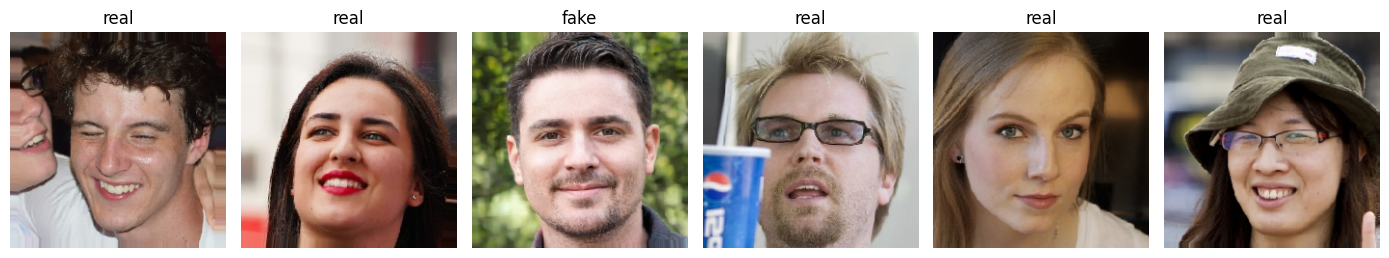

In [ ]:
images, labels = next(train_gen)

print("Batch shape :", images.shape)
print("Label sample:", labels[:8])
print("Pixel range :", images.min(), "to", images.max())
print("Class map   :", train_gen.class_indices)

plt.figure(figsize=(14, 4))
for i in range(6):
    plt.subplot(1, 6, i+1)
    plt.imshow(images[i])
    plt.title("real" if labels[i] == 1 else "fake")
    plt.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(224, 224, 3)),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     4,718,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,961,345 (18.93 MB)

 Trainable params: 4,960,641 (18.92 MB)

 Non-trainable params: 704 (2.75 KB)

In [ ]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    ModelCheckpoint('models/best_model.h5', monitor='val_accuracy', save_best_only=True)
]

history = model.fit(
    train_gen,
    epochs=10,
    validation_data=val_gen,
    callbacks=callbacks
)

Epoch 1/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 0s 395ms/step - accuracy: 0.6952 - loss: 0.6090

3125/3125 ━━━━━━━━━━━━━━━━━━━━ 1282s 407ms/step - accuracy: 0.7442 - loss: 0.5204 - val_accuracy: 0.8268 - val_loss: 0.3852
Epoch 2/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 0s 391ms/step - accuracy: 0.8278 - loss: 0.3897

3125/3125 ━━━━━━━━━━━━━━━━━━━━ 1254s 401ms/step - accuracy: 0.8416 - loss: 0.3615 - val_accuracy: 0.8827 - val_loss: 0.2812
Epoch 3/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 0s 386ms/step - accuracy: 0.8793 - loss: 0.2882

3125/3125 ━━━━━━━━━━━━━━━━━━━━ 1237s 396ms/step - accuracy: 0.8866 - loss: 0.2732 - val_accuracy: 0.9099 - val_loss: 0.2203
Epoch 4/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 0s 385ms/step - accuracy: 0.9097 - loss: 0.2220

3125/3125 ━━━━━━━━━━━━━━━━━━━━ 1233s 395ms/step - accuracy: 0.9136 - loss: 0.2125 - val_accuracy: 0.9158 - val_loss: 0.2079
Epoch 5/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 0s 388ms/step - accuracy: 0.9258 - loss: 0.1862

3125/3125 ━━━━━━━━━━━━━━━━━━━━ 1241s 397ms/step - accuracy: 0.9297 - loss: 0.1776 - val_accuracy: 0.9438 - val_loss: 0.1438
Epoch 6/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 1240s 397ms/step - accuracy: 0.9415 - loss: 0.1498 - val_accuracy: 0.9349 - val_loss: 0.1648
Epoch 7/10
 549/3125 ━━━━━━━━━━━━━━━━━━━━ 16:28 384ms/step - accuracy: 0.9469 - loss: 0.1351

KeyboardInterrupt: 

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving best_model.h5 to best_model.h5


In [ ]:
for i, layer in enumerate(model.layers):
    print(i, layer.name)

0 conv2d
1 batch_normalization
2 max_pooling2d
3 conv2d_1
4 batch_normalization_1
5 max_pooling2d_1
6 conv2d_2
7 batch_normalization_2
8 max_pooling2d_2
9 conv2d_3
10 batch_normalization_3
11 max_pooling2d_3
12 flatten
13 dense
14 dropout
15 dense_1


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import cv2
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image

model = load_model('best_model.h5')
print("Model loaded successfully")
print("Last conv layer:", model.layers[-5].name)

Model loaded successfully
Last conv layer: max_pooling2d_3


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import cv2
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image

model = load_model('best_model.h5')

# build the model by running a dummy input through it
dummy = np.zeros((1, 224, 224, 3))
model(dummy)

print("Model loaded and built successfully")
print("Layers:")
for i, layer in enumerate(model.layers):
    print(i, layer.name)

Model loaded and built successfully
Layers:
0 conv2d
1 batch_normalization
2 max_pooling2d
3 conv2d_1
4 batch_normalization_1
5 max_pooling2d_1
6 conv2d_2
7 batch_normalization_2
8 max_pooling2d_2
9 conv2d_3
10 batch_normalization_3
11 max_pooling2d_3
12 flatten
13 dense
14 dropout
15 dense_1


In [ ]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name="conv2d_3"):

    # build a function that gives us conv output + final output
    conv_layer = model.get_layer(last_conv_layer_name)

    # create sub-model from conv layer to end
    classifier_input = tf.keras.Input(shape=conv_layer.output.shape[1:])
    x = classifier_input
    for layer in model.layers[model.layers.index(conv_layer)+1:]:
        x = layer(x)
    classifier_model = tf.keras.Model(classifier_input, x)

    with tf.GradientTape() as tape:
        inputs = tf.cast(img_array, tf.float32)
        # get conv outputs
        conv_model = tf.keras.Model(model.layers[0].input, conv_layer.output)
        conv_outputs = conv_model(inputs)
        tape.watch(conv_outputs)
        predictions = classifier_model(conv_outputs)
        loss = predictions[:, 0]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

In [ ]:
def preprocess_image(img_path):
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = img_array / 255.0
    return img_array

def get_prediction(img_array):
    pred = model.predict(img_array)[0][0]
    label = "REAL" if pred > 0.5 else "FAKE"
    confidence = pred if pred > 0.5 else 1 - pred
    return label, float(confidence)

In [ ]:
def display_gradcam(img_path):
    img_array = preprocess_image(img_path)
    label, confidence = get_prediction(img_array)
    heatmap = make_gradcam_heatmap(img_array, model)

    img = cv2.imread(img_path)
    img = cv2.resize(img, (224, 224))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    heatmap_resized = cv2.resize(heatmap, (224, 224))
    heatmap_colored = np.uint8(255 * heatmap_resized)
    heatmap_colored = cv2.applyColorMap(heatmap_colored, cv2.COLORMAP_JET)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)

    superimposed = cv2.addWeighted(img_rgb, 0.6, heatmap_colored, 0.4, 0)

    plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1)
    plt.imshow(img_rgb)
    plt.title("Original")
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(heatmap_resized, cmap='jet')
    plt.title("Grad-CAM Heatmap")
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(superimposed)
    plt.title(f"{label} ({confidence:.1%} confident)")
    plt.axis('off')

    plt.tight_layout()
    plt.show()
    print(f"Verdict: {label} | Confidence: {confidence:.1%}")

Testing FAKE image:
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step


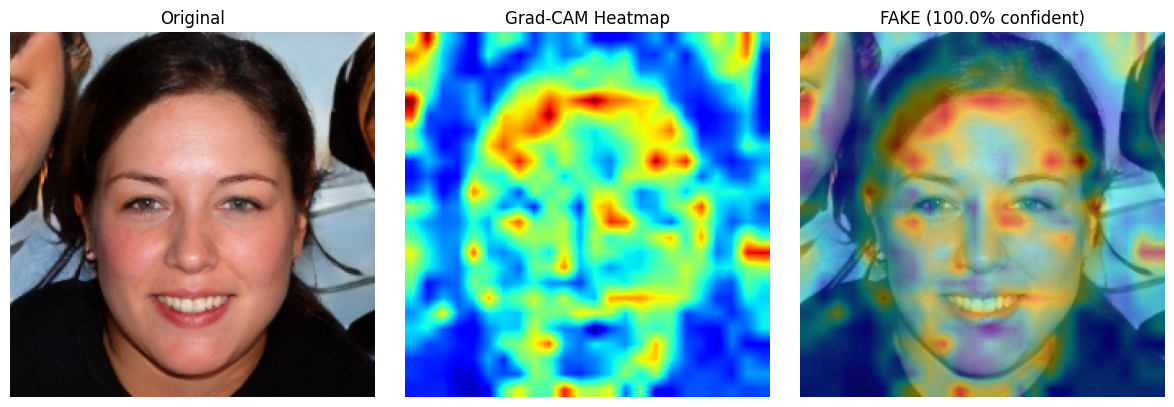

Verdict: FAKE | Confidence: 100.0%
Testing REAL image:
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step


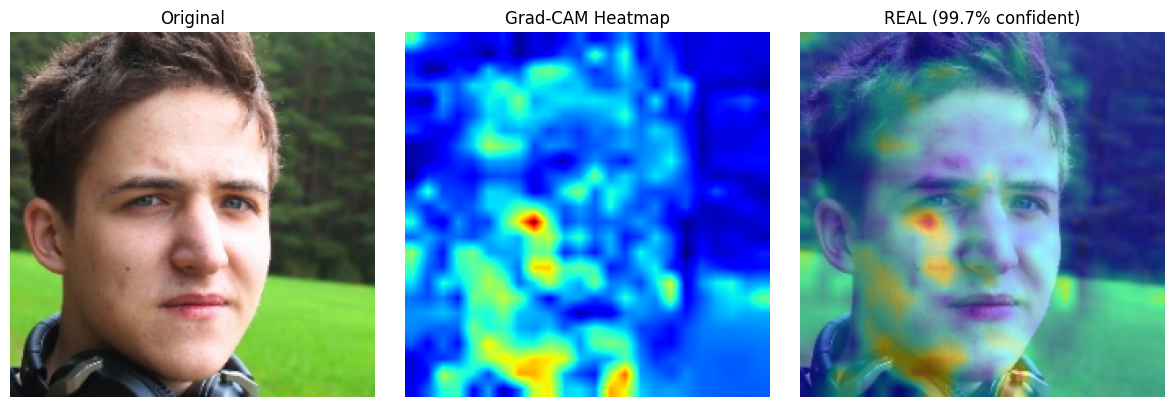

Verdict: REAL | Confidence: 99.7%


In [ ]:
import os

# grab one fake and one real image from test set
fake_dir = './data/real_vs_fake/real-vs-fake/test/fake'
real_dir = './data/real_vs_fake/real-vs-fake/test/real'

fake_img = os.path.join(fake_dir, os.listdir(fake_dir)[0])
real_img = os.path.join(real_dir, os.listdir(real_dir)[0])

print("Testing FAKE image:")
display_gradcam(fake_img)

print("Testing REAL image:")
display_gradcam(real_img)

In [ ]:
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_curve, auc, f1_score)
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# recompile model so metrics work properly
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
print("Running predictions on test set...")
y_pred_probs = model.predict(test_gen, verbose=1)
y_pred = (y_pred_probs > 0.5).astype(int).flatten()
y_true = test_gen.classes

print(f"\nTest samples: {len(y_true)}")
print(f"Class mapping: {test_gen.class_indices}")

Running predictions on test set...
625/625 ━━━━━━━━━━━━━━━━━━━━ 38s 57ms/step

Test samples: 20000
Class mapping: {'fake': 0, 'real': 1}


In [ ]:
from sklearn.metrics import accuracy_score

acc = accuracy_score(y_true, y_pred)
print(f"Test Accuracy: {acc:.4f} ({acc*100:.2f}%)")
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=['Fake', 'Real']))

Test Accuracy: 0.9443 (94.42%)

Classification Report:
              precision    recall  f1-score   support

        Fake       0.95      0.93      0.94     10000
        Real       0.94      0.95      0.94     10000

    accuracy                           0.94     20000
   macro avg       0.94      0.94      0.94     20000
weighted avg       0.94      0.94      0.94     20000



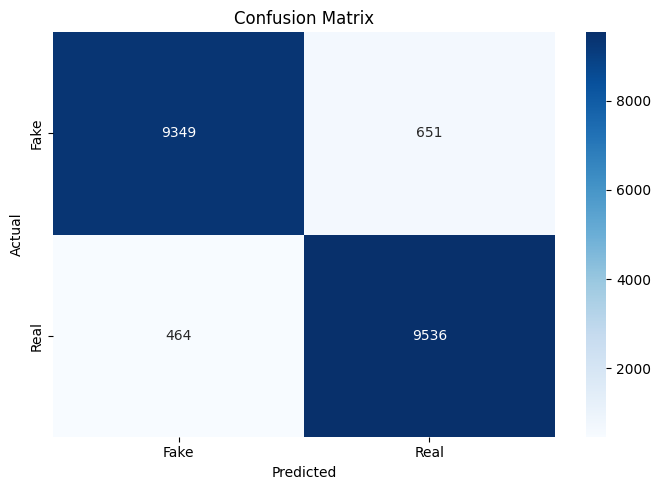

Saved as confusion_matrix.png


In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Fake', 'Real'],
            yticklabels=['Fake', 'Real'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()
print("Saved as confusion_matrix.png")

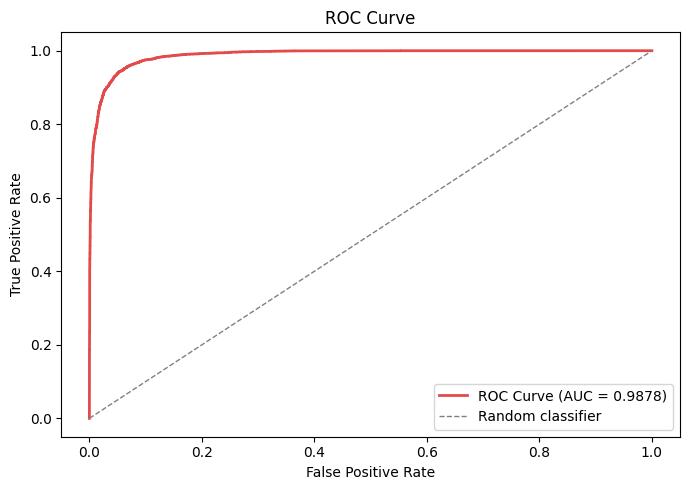

AUC-ROC: 0.9878
Saved as roc_curve.png


In [ ]:
fpr, tpr, _ = roc_curve(y_true, y_pred_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='#E24B4A', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150)
plt.show()
print(f"AUC-ROC: {roc_auc:.4f}")
print("Saved as roc_curve.png")